# Sora 2-Inspired Video Diffusion with Physics-Consistency Auxiliary Loss



In [ ]:
# 1.1 Imports and environment reporting

import os
import json
import math
import time
import random
import zipfile
import platform
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

from IPython.display import display

print('Python version:', platform.python_version())
print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Selected device:', DEVICE)

if hasattr(torch, 'set_float32_matmul_precision'):
    torch.set_float32_matmul_precision('high')

Python version: 3.12.13
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Selected device: cuda


In [ ]:
# 1.2 Reproducibility helpers

def set_seed(seed: int = 42) -> None:
    """Set random seeds for Python, NumPy, and PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # These settings improve repeatability. Exact bitwise reproducibility can
    # still vary across GPU model, CUDA version, and PyTorch version.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


GLOBAL_SEED = 42
set_seed(GLOBAL_SEED)

In [ ]:
# 1.3 Main experiment configuration

QUICK_RUN = False


@dataclass
class ExperimentConfig:
    """Central configuration for the whole artefact."""

    quick_run: bool = QUICK_RUN

    # Dataset
    image_size: int = 32
    total_frames: int = 8
    context_frames: int = 2
    ball_radius: int = 3

    # In-distribution motion range
    train_speed_min: float = 1.0
    train_speed_max: float = 2.5

    # Faster out-of-distribution motion range
    ood_speed_min: float = 2.8
    ood_speed_max: float = 4.0

    # Full-run model and diffusion settings
    diffusion_steps: int = 40
    base_channels: int = 48

    # Full-run training settings
    train_samples: int = 2400
    val_samples: int = 400
    test_samples: int = 400
    ood_test_samples: int = 400
    batch_size: int = 64
    epochs: int = 10
    learning_rate: float = 2e-3
    weight_decay: float = 1e-5
    gradient_clip_norm: float = 1.0

    # Lambda=0 is the baseline. Non-zero values are PCAL variants.
    lambda_values: Tuple[float, ...] = (0.0, 0.01, 0.05, 0.10, 0.25)

    # Evaluation
    eval_batches: int = 5
    samples_to_plot: int = 3

    # Randomness and outputs
    seed: int = GLOBAL_SEED
    output_dir: str = 'sora2_pcal_outputs'

    def apply_quick_run_overrides(self) -> None:
        """Reduce the experiment size for debugging only."""
        if self.quick_run:
            self.train_samples = 320
            self.val_samples = 80
            self.test_samples = 80
            self.ood_test_samples = 80
            self.batch_size = 32
            self.epochs = 2
            self.diffusion_steps = 20
            self.base_channels = 32
            self.eval_batches = 2
            self.lambda_values = (0.0, 0.05, 0.10)


cfg = ExperimentConfig()
cfg.apply_quick_run_overrides()

assert cfg.quick_run is False, 'This polished submission notebook should use QUICK_RUN = False.'

print('Experiment configuration:')
print(json.dumps(asdict(cfg), indent=2))

Experiment configuration:
{
  "quick_run": false,
  "image_size": 32,
  "total_frames": 8,
  "context_frames": 2,
  "ball_radius": 3,
  "train_speed_min": 1.0,
  "train_speed_max": 2.5,
  "ood_speed_min": 2.8,
  "ood_speed_max": 4.0,
  "diffusion_steps": 40,
  "base_channels": 48,
  "train_samples": 2400,
  "val_samples": 400,
  "test_samples": 400,
  "ood_test_samples": 400,
  "batch_size": 64,
  "epochs": 10,
  "learning_rate": 0.002,
  "weight_decay": 1e-05,
  "gradient_clip_norm": 1.0,
  "lambda_values": [
    0.0,
    0.01,
    0.05,
    0.1,
    0.25
  ],
  "eval_batches": 5,
  "samples_to_plot": 3,
  "seed": 42,
  "output_dir": "sora2_pcal_outputs"
}


In [ ]:
# 1.4 Output directories

OUTPUT_DIR = Path(cfg.output_dir)
FIGURE_DIR = OUTPUT_DIR / 'figures'
CSV_DIR = OUTPUT_DIR / 'csv'
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'

for directory in [OUTPUT_DIR, FIGURE_DIR, CSV_DIR, CHECKPOINT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print('Outputs will be saved under:', OUTPUT_DIR.resolve())


def save_current_figure(filename: str) -> None:
    """Save the current Matplotlib figure in a report-friendly location."""
    path = FIGURE_DIR / filename
    plt.savefig(path, dpi=180, bbox_inches='tight')
    print('Saved figure:', path)

Outputs will be saved under: /content/sora2_pcal_outputs


# 2. Dataset: physically controlled bouncing-ball videos

The dataset is synthetic but useful for evaluating motion consistency because the true object centre is known for every frame.

Each sequence has:

- 8 frames.
- 2 observed context frames.
- 6 generated future frames.
- Elastic boundary reflections.
- Known centre positions $(x_t, y_t)$.

The held-out OOD set uses faster motion than training.

In [ ]:
# 2.1 Bouncing-ball simulator

def draw_ball(frame: np.ndarray, cx: float, cy: float, radius: int) -> None:
    """Draw a filled circular ball into a 2D image."""
    height, width = frame.shape
    yy, xx = np.ogrid[:height, :width]
    mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2
    frame[mask] = 1.0


def generate_bouncing_ball_sequence(
    total_frames: int,
    image_size: int,
    radius: int,
    speed_min: float,
    speed_max: float,
    rng: np.random.Generator,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate one video sequence with an elastic bouncing ball.

    Returns:
        frames: [T, H, W]
        positions: [T, 2], where columns are x and y centre coordinates
    """
    lower = radius + 1
    upper = image_size - radius - 2

    x = rng.uniform(lower, upper)
    y = rng.uniform(lower, upper)

    angle = rng.uniform(0.0, 2.0 * np.pi)
    speed = rng.uniform(speed_min, speed_max)
    vx = speed * np.cos(angle)
    vy = speed * np.sin(angle)

    frames = np.zeros((total_frames, image_size, image_size), dtype=np.float32)
    positions = np.zeros((total_frames, 2), dtype=np.float32)

    for t in range(total_frames):
        draw_ball(frames[t], x, y, radius)
        positions[t] = np.array([x, y], dtype=np.float32)

        next_x = x + vx
        next_y = y + vy

        if next_x < lower or next_x > upper:
            vx *= -1.0
            next_x = np.clip(x + vx, lower, upper)

        if next_y < lower or next_y > upper:
            vy *= -1.0
            next_y = np.clip(y + vy, lower, upper)

        x, y = next_x, next_y

    return frames, positions


class BouncingBallDataset(Dataset):
    """
    In-memory deterministic dataset generated from a fixed NumPy seed.
    """

    def __init__(
        self,
        n_samples: int,
        total_frames: int,
        image_size: int,
        radius: int,
        speed_min: float,
        speed_max: float,
        seed: int,
    ) -> None:
        rng = np.random.default_rng(seed)
        videos = []
        positions = []

        for _ in range(n_samples):
            frames, centres = generate_bouncing_ball_sequence(
                total_frames=total_frames,
                image_size=image_size,
                radius=radius,
                speed_min=speed_min,
                speed_max=speed_max,
                rng=rng,
            )
            videos.append(frames)
            positions.append(centres)

        self.videos = torch.tensor(np.stack(videos), dtype=torch.float32)
        self.positions = torch.tensor(np.stack(positions), dtype=torch.float32)

    def __len__(self) -> int:
        return self.videos.shape[0]

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.videos[index], self.positions[index]

In [ ]:
# 2.2 Build deterministic train/validation/test splits

train_ds = BouncingBallDataset(
    n_samples=cfg.train_samples,
    total_frames=cfg.total_frames,
    image_size=cfg.image_size,
    radius=cfg.ball_radius,
    speed_min=cfg.train_speed_min,
    speed_max=cfg.train_speed_max,
    seed=cfg.seed,
)

val_ds = BouncingBallDataset(
    n_samples=cfg.val_samples,
    total_frames=cfg.total_frames,
    image_size=cfg.image_size,
    radius=cfg.ball_radius,
    speed_min=cfg.train_speed_min,
    speed_max=cfg.train_speed_max,
    seed=cfg.seed + 1,
)

test_ds = BouncingBallDataset(
    n_samples=cfg.test_samples,
    total_frames=cfg.total_frames,
    image_size=cfg.image_size,
    radius=cfg.ball_radius,
    speed_min=cfg.train_speed_min,
    speed_max=cfg.train_speed_max,
    seed=cfg.seed + 2,
)

ood_test_ds = BouncingBallDataset(
    n_samples=cfg.ood_test_samples,
    total_frames=cfg.total_frames,
    image_size=cfg.image_size,
    radius=cfg.ball_radius,
    speed_min=cfg.ood_speed_min,
    speed_max=cfg.ood_speed_max,
    seed=cfg.seed + 3,
)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)
ood_test_loader = DataLoader(ood_test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

print(f'Training samples:   {len(train_ds)}')
print(f'Validation samples: {len(val_ds)}')
print(f'Test samples:       {len(test_ds)}')
print(f'OOD test samples:   {len(ood_test_ds)}')

Training samples:   2400
Validation samples: 400
Test samples:       400
OOD test samples:   400


Saved figure: sora2_pcal_outputs/figures/dataset_example_sequence.png


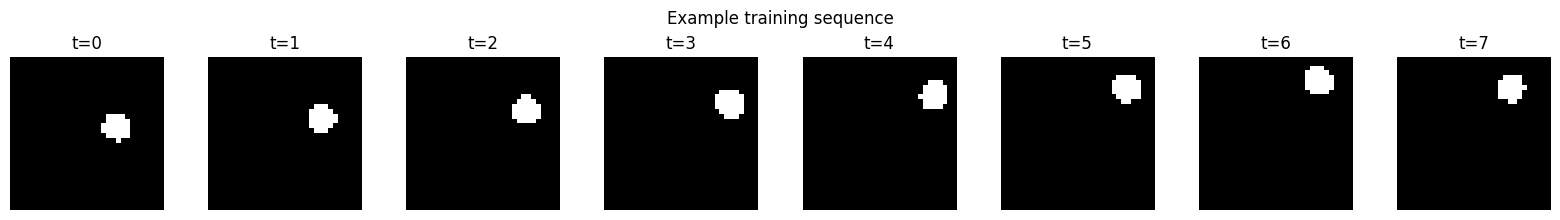

,x_position,y_position
0,21.800989,14.094204
1,23.091253,12.506266
2,24.381517,10.918327
3,25.671782,9.330389
4,26.962046,7.742451
5,25.671782,6.154513
6,24.381517,4.566575
7,23.091253,6.154513


In [ ]:
# 2.3 Dataset visualisation

def show_video_strip(video: torch.Tensor, title: str, filename: Optional[str] = None) -> None:
    """Display one video as a horizontal strip of frames."""
    video_np = video.detach().cpu().numpy()
    n_frames = video_np.shape[0]

    plt.figure(figsize=(2.0 * n_frames, 2.2))
    for t in range(n_frames):
        ax = plt.subplot(1, n_frames, t + 1)
        ax.imshow(video_np[t], cmap='gray', vmin=0.0, vmax=1.0)
        ax.set_title(f't={t}')
        ax.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    if filename is not None:
        save_current_figure(filename)
    plt.show()


sample_video, sample_positions = train_ds[0]
show_video_strip(sample_video, 'Example training sequence', 'dataset_example_sequence.png')
display(pd.DataFrame(sample_positions.numpy(), columns=['x_position', 'y_position']))

# 3. Baseline model: lightweight conditional video diffusion

The baseline is a conditional denoising network:

$$
\epsilon_\theta(x_t,t,c)
$$

where $x_t$ is a noisy future video, $t$ is the diffusion timestep, and $c$ is the observed context video. The output predicts the noise added during diffusion.


In [ ]:
# 3.1 Model definition

def sinusoidal_embedding(timesteps: torch.Tensor, dim: int) -> torch.Tensor:
    """Create sinusoidal embeddings for integer diffusion timesteps."""
    half_dim = dim // 2
    exponent = -math.log(10000.0) * torch.arange(
        half_dim, device=timesteps.device
    ) / max(half_dim - 1, 1)
    frequencies = torch.exp(exponent)
    angles = timesteps.float().unsqueeze(1) * frequencies.unsqueeze(0)
    embedding = torch.cat([torch.sin(angles), torch.cos(angles)], dim=1)

    if dim % 2 == 1:
        embedding = F.pad(embedding, (0, 1))

    return embedding


class ResidualBlock(nn.Module):
    """Residual convolutional block conditioned on diffusion timestep."""

    def __init__(self, channels: int, time_dim: int) -> None:
        super().__init__()
        groups = 8 if channels >= 8 else 1
        self.norm1 = nn.GroupNorm(groups, channels)
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(groups, channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.time_projection = nn.Linear(time_dim, channels)

    def forward(self, x: torch.Tensor, time_embedding: torch.Tensor) -> torch.Tensor:
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_projection(time_embedding).unsqueeze(-1).unsqueeze(-1)
        h = self.conv2(F.silu(self.norm2(h)))
        return x + h


class TinyConditionalVideoDenoiser(nn.Module):
    """
    Compact conditional video denoiser.

    Input:
        noisy_future: [B, future_frames, H, W]
        context:      [B, context_frames, H, W]
        timesteps:    [B]

    Output:
        predicted noise for future frames: [B, future_frames, H, W]
    """

    def __init__(self, context_frames: int, future_frames: int, base_channels: int) -> None:
        super().__init__()
        self.context_frames = context_frames
        self.future_frames = future_frames
        self.time_dim = base_channels * 2

        input_channels = context_frames + future_frames

        self.time_mlp = nn.Sequential(
            nn.Linear(self.time_dim, self.time_dim),
            nn.SiLU(),
            nn.Linear(self.time_dim, self.time_dim),
        )

        self.input_conv = nn.Conv2d(input_channels, base_channels, kernel_size=3, padding=1)
        self.block1 = ResidualBlock(base_channels, self.time_dim)
        self.block2 = ResidualBlock(base_channels, self.time_dim)
        self.block3 = ResidualBlock(base_channels, self.time_dim)
        self.block4 = ResidualBlock(base_channels, self.time_dim)
        self.output_norm = nn.GroupNorm(8 if base_channels >= 8 else 1, base_channels)
        self.output_conv = nn.Conv2d(base_channels, future_frames, kernel_size=3, padding=1)

    def forward(self, noisy_future: torch.Tensor, context: torch.Tensor, timesteps: torch.Tensor) -> torch.Tensor:
        t_emb = sinusoidal_embedding(timesteps, self.time_dim)
        t_emb = self.time_mlp(t_emb)

        x = torch.cat([noisy_future, context], dim=1)
        x = self.input_conv(x)
        x = self.block1(x, t_emb)
        x = self.block2(x, t_emb)
        x = self.block3(x, t_emb)
        x = self.block4(x, t_emb)
        return self.output_conv(F.silu(self.output_norm(x)))

In [ ]:
# 3.2 Architecture sanity check

future_frames = cfg.total_frames - cfg.context_frames

sanity_model = TinyConditionalVideoDenoiser(
    context_frames=cfg.context_frames,
    future_frames=future_frames,
    base_channels=cfg.base_channels,
).to(DEVICE)

parameter_count = sum(p.numel() for p in sanity_model.parameters())
print(f'Model parameter count: {parameter_count:,}')

batch_video, _ = next(iter(train_loader))
batch_video = batch_video.to(DEVICE)
context = batch_video[:, :cfg.context_frames]
future = batch_video[:, cfg.context_frames:]
dummy_timesteps = torch.randint(0, cfg.diffusion_steps, (batch_video.shape[0],), device=DEVICE)
dummy_output = sanity_model(future, context, dummy_timesteps)

print('Context shape:', tuple(context.shape))
print('Future shape:', tuple(future.shape))
print('Output shape:', tuple(dummy_output.shape))

Model parameter count: 210,486
Context shape: (64, 2, 32, 32)
Future shape: (64, 6, 32, 32)
Output shape: (64, 6, 32, 32)


# 4. Diffusion objective

The standard noise-prediction objective is:

$$
L_{\text{noise}} =
\mathbb{E}_{x_0,t,\epsilon}
\left[\|\epsilon-\epsilon_\theta(x_t,t,c)\|_2^2\right]
$$

where:

$$
x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon.
$$

The baseline uses only $L_{\text{noise}}$.

In [ ]:
# 4.1 Diffusion schedule

class DiffusionSchedule:
    """Pre-computed DDPM schedule tensors."""

    def __init__(self, steps: int, device: torch.device) -> None:
        self.steps = steps
        betas = torch.linspace(1e-4, 0.02, steps, device=device)
        alphas = 1.0 - betas
        alpha_bars = torch.cumprod(alphas, dim=0)

        self.betas = betas
        self.alphas = alphas
        self.alpha_bars = alpha_bars
        self.sqrt_alpha_bars = torch.sqrt(alpha_bars)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - alpha_bars)

    @staticmethod
    def extract(values: torch.Tensor, timesteps: torch.Tensor, target_shape: torch.Size) -> torch.Tensor:
        """Gather schedule values and reshape for broadcasting."""
        out = values.gather(0, timesteps)
        return out.reshape(timesteps.shape[0], *((1,) * (len(target_shape) - 1)))


schedule = DiffusionSchedule(cfg.diffusion_steps, DEVICE)


def q_sample(x0: torch.Tensor, timesteps: torch.Tensor, noise: torch.Tensor) -> torch.Tensor:
    """Forward diffusion process q(x_t | x_0)."""
    sqrt_ab = schedule.extract(schedule.sqrt_alpha_bars, timesteps, x0.shape)
    sqrt_one_minus_ab = schedule.extract(schedule.sqrt_one_minus_alpha_bars, timesteps, x0.shape)
    return sqrt_ab * x0 + sqrt_one_minus_ab * noise


def predict_x0_from_noise(xt: torch.Tensor, timesteps: torch.Tensor, predicted_noise: torch.Tensor) -> torch.Tensor:
    """Estimate clean x_0 from noisy x_t and predicted noise."""
    sqrt_ab = schedule.extract(schedule.sqrt_alpha_bars, timesteps, xt.shape)
    sqrt_one_minus_ab = schedule.extract(schedule.sqrt_one_minus_alpha_bars, timesteps, xt.shape)
    return (xt - sqrt_one_minus_ab * predicted_noise) / torch.clamp(sqrt_ab, min=1e-8)

# 5. Proposed extension: Physics-Consistency Auxiliary Loss

For a generated clean-video estimate $\hat{x}_0$, define first-order temporal velocity:

$$
v_t = \hat{x}_{0,t+1} - \hat{x}_{0,t}
$$

and second-order temporal acceleration:

$$
a_t = v_t - v_{t-1}
    = \hat{x}_{0,t+1} - 2\hat{x}_{0,t} + \hat{x}_{0,t-1}.
$$

The auxiliary loss is:

$$
L_{\text{PCAL}} =
\frac{1}{T-2}\sum_{t=2}^{T-1}
\left\|\hat{x}_{0,t+1} - 2\hat{x}_{0,t} + \hat{x}_{0,t-1}\right\|_1.
$$

The proposed total objective is:

$$
L_{\text{total}} = L_{\text{noise}} + \lambda L_{\text{PCAL}}.
$$

PCAL penalises abrupt changes in temporal acceleration. It is a physics-inspired regulariser, not a full physical simulator.

In [ ]:
# 5.1 PCAL implementation and sanity checks

def pcal_loss(full_video_estimate: torch.Tensor) -> torch.Tensor:
    """
    Physics-Consistency Auxiliary Loss.

    full_video_estimate shape: [B, T, H, W]
    """
    acceleration = (
        full_video_estimate[:, 2:]
        - 2.0 * full_video_estimate[:, 1:-1]
        + full_video_estimate[:, :-2]
    )
    return acceleration.abs().mean()


constant_video = torch.ones(2, cfg.total_frames, cfg.image_size, cfg.image_size)
jittered_video = constant_video.clone()
jittered_video[:, 3] = 0.0

print('PCAL constant video:', float(pcal_loss(constant_video)))
print('PCAL jittered video:', float(pcal_loss(jittered_video)))

PCAL constant video: 0.0
PCAL jittered video: 0.6666666865348816


# 6. Training and validation

Only $\lambda$ changes between experiments. This isolates the effect of PCAL.

In [ ]:
# 6.1 Training functions

def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimiser: Optional[torch.optim.Optimizer],
    lambda_pcal: float,
) -> Dict[str, float]:
    """Run one training or validation epoch."""
    is_training = optimiser is not None
    model.train(is_training)

    totals = {'total_loss': 0.0, 'noise_loss': 0.0, 'pcal_loss': 0.0}
    n_examples = 0

    iterator = tqdm(loader, leave=False, desc='train' if is_training else 'eval')

    for videos, _positions in iterator:
        videos = videos.to(DEVICE)
        context = videos[:, :cfg.context_frames]
        clean_future = videos[:, cfg.context_frames:]

        batch_size = videos.shape[0]
        timesteps = torch.randint(0, cfg.diffusion_steps, (batch_size,), device=DEVICE)
        noise = torch.randn_like(clean_future)
        noisy_future = q_sample(clean_future, timesteps, noise)

        with torch.set_grad_enabled(is_training):
            predicted_noise = model(noisy_future, context, timesteps)
            noise_loss = F.mse_loss(predicted_noise, noise)

            estimated_future = predict_x0_from_noise(noisy_future, timesteps, predicted_noise)
            estimated_future = estimated_future.clamp(0.0, 1.0)
            estimated_full_video = torch.cat([context, estimated_future], dim=1)

            temporal_loss = pcal_loss(estimated_full_video)
            total_loss = noise_loss + lambda_pcal * temporal_loss

            if is_training:
                optimiser.zero_grad(set_to_none=True)
                total_loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), cfg.gradient_clip_norm)
                optimiser.step()

        totals['total_loss'] += float(total_loss.detach()) * batch_size
        totals['noise_loss'] += float(noise_loss.detach()) * batch_size
        totals['pcal_loss'] += float(temporal_loss.detach()) * batch_size
        n_examples += batch_size

    return {key: value / n_examples for key, value in totals.items()}


def train_single_model(lambda_pcal: float, seed: int) -> Tuple[nn.Module, pd.DataFrame, float]:
    """Train one model for a specified PCAL weight."""
    set_seed(seed)

    model = TinyConditionalVideoDenoiser(
        context_frames=cfg.context_frames,
        future_frames=future_frames,
        base_channels=cfg.base_channels,
    ).to(DEVICE)

    optimiser = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )

    history = []
    start_time = time.perf_counter()

    for epoch in range(1, cfg.epochs + 1):
        train_metrics = run_epoch(model, train_loader, optimiser, lambda_pcal)
        val_metrics = run_epoch(model, val_loader, None, lambda_pcal)

        row = {
            'lambda_pcal': lambda_pcal,
            'epoch': epoch,
            'train_total_loss': train_metrics['total_loss'],
            'train_noise_loss': train_metrics['noise_loss'],
            'train_pcal_loss': train_metrics['pcal_loss'],
            'val_total_loss': val_metrics['total_loss'],
            'val_noise_loss': val_metrics['noise_loss'],
            'val_pcal_loss': val_metrics['pcal_loss'],
        }
        history.append(row)

        print(
            f"λ={lambda_pcal:>5} | "
            f"epoch {epoch:02d}/{cfg.epochs} | "
            f"train total={row['train_total_loss']:.4f} | "
            f"val total={row['val_total_loss']:.4f} | "
            f"val noise={row['val_noise_loss']:.4f} | "
            f"val PCAL={row['val_pcal_loss']:.4f}"
        )

    elapsed_seconds = time.perf_counter() - start_time
    return model, pd.DataFrame(history), elapsed_seconds

In [ ]:
# 6.2 Train baseline and PCAL ablation models

models: Dict[float, nn.Module] = {}
histories: Dict[float, pd.DataFrame] = {}
training_times: Dict[float, float] = {}

for lambda_value in cfg.lambda_values:
    print('\n' + '=' * 90)
    if lambda_value == 0.0:
        print('Training BASELINE model: diffusion loss only')
    else:
        print(f'Training PROPOSED model: diffusion loss + λ PCAL, λ={lambda_value}')

    model, history, elapsed = train_single_model(lambda_value, cfg.seed)
    models[lambda_value] = model
    histories[lambda_value] = history
    training_times[lambda_value] = elapsed

    checkpoint_path = CHECKPOINT_DIR / f'denoiser_lambda_{lambda_value}.pt'
    torch.save(
        {
            'model_state_dict': model.state_dict(),
            'lambda_pcal': lambda_value,
            'config': asdict(cfg),
            'parameter_count': parameter_count,
        },
        checkpoint_path,
    )
    print(f'Saved checkpoint: {checkpoint_path}')
    print(f'Training seconds: {elapsed:.2f}')

history_df = pd.concat(histories.values(), ignore_index=True)
history_csv = CSV_DIR / 'training_history.csv'
history_df.to_csv(history_csv, index=False)

print('\nTraining history saved to:', history_csv)
display(history_df)


Training BASELINE model: diffusion loss only


train:   0%|          | 0/38 [00:00<?, ?it/s]

eval:   0%|          | 0/7 [00:00<?, ?it/s]

λ=  0.0 | epoch 01/10 | train total=0.4282 | val total=0.1646 | val noise=0.1646 | val PCAL=0.1402


train:   0%|          | 0/38 [00:00<?, ?it/s]

...

λ= 0.25 | epoch 09/10 | train total=0.0609 | val total=0.0672 | val noise=0.0542 | val PCAL=0.0517


train:   0%|          | 0/38 [00:00<?, ?it/s]

eval:   0%|          | 0/7 [00:00<?, ?it/s]

λ= 0.25 | epoch 10/10 | train total=0.0606 | val total=0.0555 | val noise=0.0441 | val PCAL=0.0456
Saved checkpoint: sora2_pcal_outputs/checkpoints/denoiser_lambda_0.25.pt
Training seconds: 24.26

Training history saved to: sora2_pcal_outputs/csv/training_history.csv


,lambda_pcal,epoch,train_total_loss,train_noise_loss,train_pcal_loss,val_total_loss,val_noise_loss,val_pcal_loss
0,0.00,1,0.428166,0.428166,0.198697,0.164636,0.164636,0.140204
1,0.00,2,0.131377,0.131377,0.111466,0.109446,0.109446,0.096346
2,0.00,3,0.099784,0.099784,0.095656,0.082744,0.082744,0.084107
3,0.00,4,0.079192,0.079192,0.083678,0.074240,0.074240,0.095173
4,0.00,5,0.067981,0.067981,0.078769,0.064028,0.064028,0.064974
5,0.00,6,0.059118,0.059118,0.071366,0.057422,0.057422,0.065587
6,0.00,7,0.053751,0.053751,0.068954,0.050739,0.050739,0.066370
7,0.00,8,0.051377,0.051377,0.065181,0.047024,0.047024,0.059980
8,0.00,9,0.047583,0.047583,0.062966,0.047520,0.047520,0.059274
9,0.00,10,0.047111,0.047111,0.061466,0.045315,0.045315,0.068448


Saved figure: sora2_pcal_outputs/figures/validation_diffusion_loss.png


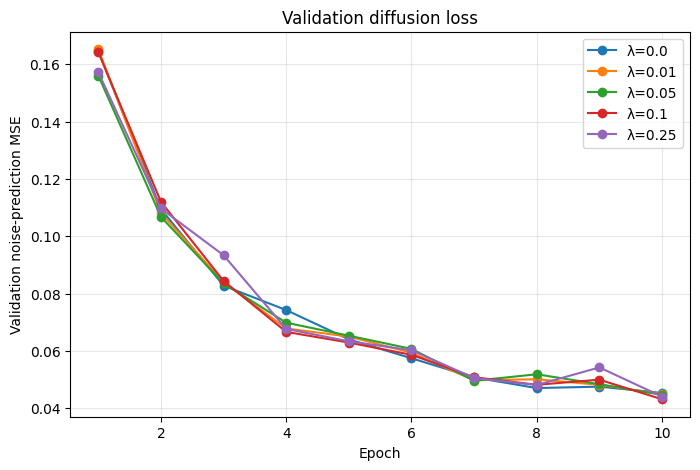

Saved figure: sora2_pcal_outputs/figures/validation_pcal_loss.png


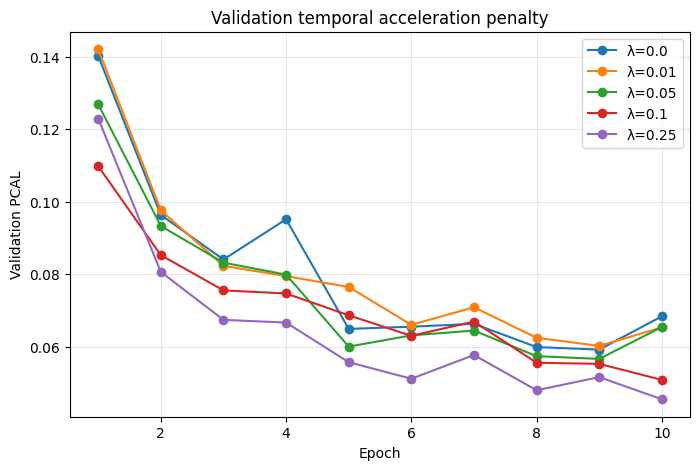

In [ ]:
# 6.3 Training and validation curves

plt.figure(figsize=(8, 5))
for lambda_value, history in histories.items():
    plt.plot(history['epoch'], history['val_noise_loss'], marker='o', label=f'λ={lambda_value}')
plt.xlabel('Epoch')
plt.ylabel('Validation noise-prediction MSE')
plt.title('Validation diffusion loss')
plt.grid(True, alpha=0.3)
plt.legend()
save_current_figure('validation_diffusion_loss.png')
plt.show()

plt.figure(figsize=(8, 5))
for lambda_value, history in histories.items():
    plt.plot(history['epoch'], history['val_pcal_loss'], marker='o', label=f'λ={lambda_value}')
plt.xlabel('Epoch')
plt.ylabel('Validation PCAL')
plt.title('Validation temporal acceleration penalty')
plt.grid(True, alpha=0.3)
plt.legend()
save_current_figure('validation_pcal_loss.png')
plt.show()

# 7. Reverse-diffusion sampling

Sampling begins from Gaussian noise and iteratively denoises the future frames while conditioning on the first two context frames.

In [ ]:
# 7.1 Sampler

@torch.no_grad()
def sample_future(model: nn.Module, context: torch.Tensor, seed: Optional[int] = None) -> torch.Tensor:
    """Generate future frames using the reverse diffusion process."""
    model.eval()

    if seed is not None:
        generator_device = 'cuda' if DEVICE.type == 'cuda' else 'cpu'
        generator = torch.Generator(device=generator_device)
        generator.manual_seed(seed)
    else:
        generator = None

    batch_size = context.shape[0]
    x = torch.randn(
        (batch_size, future_frames, cfg.image_size, cfg.image_size),
        device=DEVICE,
        generator=generator,
    )

    for step in reversed(range(cfg.diffusion_steps)):
        timesteps = torch.full((batch_size,), step, device=DEVICE, dtype=torch.long)
        predicted_noise = model(x, context, timesteps)

        alpha_t = schedule.alphas[step]
        alpha_bar_t = schedule.alpha_bars[step]
        beta_t = schedule.betas[step]

        mean = (x - (beta_t / torch.sqrt(1.0 - alpha_bar_t)) * predicted_noise) / torch.sqrt(alpha_t)

        if step > 0:
            random_noise = torch.randn(x.shape, device=DEVICE, generator=generator)
            x = mean + torch.sqrt(beta_t) * random_noise
        else:
            x = mean

    return x.clamp(0.0, 1.0)

# 8. Quantitative evaluation metrics



In [ ]:
# 8.1 Metric helpers

def extract_centres(videos: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Estimate object centre coordinates by intensity-weighted centre of mass.

    videos shape: [B, T, H, W]
    returns shape: [B, T, 2], where columns are x and y.
    """
    _, _, h, w = videos.shape
    yy, xx = torch.meshgrid(
        torch.arange(h, device=videos.device, dtype=videos.dtype),
        torch.arange(w, device=videos.device, dtype=videos.dtype),
        indexing='ij',
    )

    weights = videos.clamp(min=0.0)
    mass = weights.sum(dim=(-2, -1)).clamp(min=eps)
    x = (weights * xx).sum(dim=(-2, -1)) / mass
    y = (weights * yy).sum(dim=(-2, -1)) / mass
    return torch.stack([x, y], dim=-1)


def psnr_from_mse(mse_value: float, max_pixel_value: float = 1.0) -> float:
    """Compute PSNR from MSE."""
    if mse_value <= 0:
        return float('inf')
    return 20.0 * math.log10(max_pixel_value) - 10.0 * math.log10(mse_value)


def global_ssim_proxy(x: torch.Tensor, y: torch.Tensor) -> float:
    """
    Compute a lightweight global SSIM-style score without external dependencies.

    This is not a windowed SSIM implementation. It is used as a reproducible
    structural proxy for this controlled experiment.
    """
    c1 = 0.01 ** 2
    c2 = 0.03 ** 2

    x_flat = x.reshape(x.shape[0], -1)
    y_flat = y.reshape(y.shape[0], -1)

    mu_x = x_flat.mean(dim=1)
    mu_y = y_flat.mean(dim=1)
    var_x = x_flat.var(dim=1, unbiased=False)
    var_y = y_flat.var(dim=1, unbiased=False)
    cov_xy = ((x_flat - mu_x[:, None]) * (y_flat - mu_y[:, None])).mean(dim=1)

    numerator = (2 * mu_x * mu_y + c1) * (2 * cov_xy + c2)
    denominator = (mu_x ** 2 + mu_y ** 2 + c1) * (var_x + var_y + c2)
    return float((numerator / denominator.clamp(min=1e-8)).mean().detach().cpu())


def compute_all_metrics(generated_full: torch.Tensor, target_full: torch.Tensor, target_positions: torch.Tensor) -> Dict[str, float]:
    """Compute frame-level and trajectory-level metrics."""
    future_slice = slice(cfg.context_frames, cfg.total_frames)

    generated_future = generated_full[:, future_slice]
    target_future = target_full[:, future_slice]

    future_mse = F.mse_loss(generated_future, target_future).item()
    future_mae = F.l1_loss(generated_future, target_future).item()
    future_psnr = psnr_from_mse(future_mse)
    future_ssim_proxy = global_ssim_proxy(generated_future, target_future)

    predicted_positions = extract_centres(generated_full)

    position_error = torch.linalg.norm(
        predicted_positions[:, future_slice] - target_positions[:, future_slice],
        dim=-1,
    ).mean().item()

    predicted_velocity = predicted_positions[:, 1:] - predicted_positions[:, :-1]
    true_velocity = target_positions[:, 1:] - target_positions[:, :-1]

    velocity_error = torch.linalg.norm(
        predicted_velocity[:, cfg.context_frames - 1:] - true_velocity[:, cfg.context_frames - 1:],
        dim=-1,
    ).mean().item()

    predicted_acceleration = predicted_velocity[:, 1:] - predicted_velocity[:, :-1]
    true_acceleration = true_velocity[:, 1:] - true_velocity[:, :-1]

    start_accel_index = max(cfg.context_frames - 2, 0)
    acceleration_error = torch.linalg.norm(
        predicted_acceleration[:, start_accel_index:] - true_acceleration[:, start_accel_index:],
        dim=-1,
    ).mean().item()

    predicted_acceleration_magnitude = torch.linalg.norm(
        predicted_acceleration[:, start_accel_index:],
        dim=-1,
    ).mean().item()

    lower = cfg.ball_radius
    upper = cfg.image_size - cfg.ball_radius - 1
    future_positions = predicted_positions[:, future_slice]
    boundary_violation_rate = (
        (future_positions[..., 0] < lower)
        | (future_positions[..., 0] > upper)
        | (future_positions[..., 1] < lower)
        | (future_positions[..., 1] > upper)
    ).float().mean().item()

    return {
        'future_mse': future_mse,
        'future_mae': future_mae,
        'future_psnr': future_psnr,
        'global_ssim_proxy': future_ssim_proxy,
        'position_error': position_error,
        'velocity_error': velocity_error,
        'acceleration_error': acceleration_error,
        'predicted_acceleration_magnitude': predicted_acceleration_magnitude,
        'boundary_violation_rate': boundary_violation_rate,
    }

In [ ]:
# 8.2 Evaluation loop

@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, max_batches: int, sampling_seed: int) -> Dict[str, float]:
    """Evaluate one trained model on a given split."""
    all_metrics: Dict[str, List[float]] = {}
    sampling_times = []

    for batch_index, (videos, positions) in enumerate(tqdm(loader, desc='evaluate', leave=False)):
        if batch_index >= max_batches:
            break

        videos = videos.to(DEVICE)
        positions = positions.to(DEVICE)
        context = videos[:, :cfg.context_frames]

        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()

        start = time.perf_counter()
        predicted_future = sample_future(model, context, seed=sampling_seed + batch_index)

        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()

        sampling_times.append(time.perf_counter() - start)
        generated_full = torch.cat([context, predicted_future], dim=1)
        metrics = compute_all_metrics(generated_full, videos, positions)

        for key, value in metrics.items():
            all_metrics.setdefault(key, []).append(value)

    result = {key: float(np.mean(values)) for key, values in all_metrics.items()}
    result['sampling_seconds_per_batch'] = float(np.mean(sampling_times))
    return result

# 9. Evaluate in-distribution and OOD performance

The proposed PCAL weight is selected using validation evidence, while final performance is reported on held-out test data.

Selection rule:

1. Prefer a non-zero $\lambda$ if its validation noise loss is not more than 15% worse than the baseline.
2. Among eligible values, choose the lowest validation PCAL.
3. If no value is eligible, choose the non-zero $\lambda$ with the lowest validation total loss.

In [ ]:
# 9.1 Select proposed PCAL model using validation results

final_val_rows = history_df.sort_values('epoch').groupby('lambda_pcal').tail(1).copy()
baseline_val_noise = float(
    final_val_rows.loc[final_val_rows['lambda_pcal'] == 0.0, 'val_noise_loss'].iloc[0]
)

eligible = final_val_rows[
    (final_val_rows['lambda_pcal'] > 0.0)
    & (final_val_rows['val_noise_loss'] <= baseline_val_noise * 1.15)
].copy()

if len(eligible) > 0:
    best_lambda = float(eligible.sort_values('val_pcal_loss').iloc[0]['lambda_pcal'])
    selection_reason = 'lowest validation PCAL among non-zero lambdas within 15% of baseline validation noise loss'
else:
    nonzero_rows = final_val_rows[final_val_rows['lambda_pcal'] > 0.0]
    best_lambda = float(nonzero_rows.sort_values('val_total_loss').iloc[0]['lambda_pcal'])
    selection_reason = 'lowest validation total loss among non-zero lambdas because no value met the 15% noise-loss rule'

print('Selected proposed PCAL λ:', best_lambda)
print('Selection rule:', selection_reason)
display(final_val_rows.sort_values('lambda_pcal'))

Selected proposed PCAL λ: 0.25
Selection rule: lowest validation PCAL among non-zero lambdas within 15% of baseline validation noise loss


,lambda_pcal,epoch,train_total_loss,train_noise_loss,train_pcal_loss,val_total_loss,val_noise_loss,val_pcal_loss
9,0.00,10,0.047111,0.047111,0.061466,0.045315,0.045315,0.068448
19,0.01,10,0.047499,0.046892,0.060653,0.045549,0.044895,0.065380
29,0.05,10,0.050421,0.047522,0.057981,0.047935,0.044661,0.065488
39,0.10,10,0.052045,0.046648,0.053969,0.048224,0.043131,0.050924
49,0.25,10,0.060556,0.048471,0.048340,0.055469,0.044067,0.045607


In [ ]:
# 9.2 Evaluate all lambda values on ID and OOD test sets

evaluation_rows = []

for lambda_value, model in models.items():
    print('\nEvaluating λ =', lambda_value)

    id_metrics = evaluate_model(
        model,
        test_loader,
        max_batches=cfg.eval_batches,
        sampling_seed=cfg.seed + 1000,
    )

    ood_metrics = evaluate_model(
        model,
        ood_test_loader,
        max_batches=cfg.eval_batches,
        sampling_seed=cfg.seed + 2000,
    )

    for split_name, metrics in [('ID_test', id_metrics), ('OOD_fast_motion_test', ood_metrics)]:
        row = {
            'lambda_pcal': lambda_value,
            'split': split_name,
            'training_seconds': training_times[lambda_value],
            'parameter_count': parameter_count,
            **metrics,
        }
        evaluation_rows.append(row)

results_df = pd.DataFrame(evaluation_rows)
results_csv = CSV_DIR / 'evaluation_metrics.csv'
results_df.to_csv(results_csv, index=False)

print('Evaluation metrics saved to:', results_csv)
display(results_df.sort_values(['split', 'lambda_pcal']))


Evaluating λ = 0.0


evaluate:   0%|          | 0/7 [00:00<?, ?it/s]

evaluate:   0%|          | 0/7 [00:00<?, ?it/s]


Evaluating λ = 0.01


evaluate:   0%|          | 0/7 [00:00<?, ?it/s]

...


Evaluating λ = 0.25


evaluate:   0%|          | 0/7 [00:00<?, ?it/s]

evaluate:   0%|          | 0/7 [00:00<?, ?it/s]

Evaluation metrics saved to: sora2_pcal_outputs/csv/evaluation_metrics.csv


,lambda_pcal,split,training_seconds,parameter_count,future_mse,future_mae,future_psnr,global_ssim_proxy,position_error,velocity_error,acceleration_error,predicted_acceleration_magnitude,boundary_violation_rate,sampling_seconds_per_batch
0,0.00,ID_test,22.958103,210486,0.027648,0.052545,15.583394,0.090326,8.005621,3.391449,4.816631,4.740521,0.000521,0.433391
2,0.01,ID_test,22.631032,210486,0.027565,0.051842,15.596455,0.090594,7.913424,3.136249,4.112996,4.040421,0.000000,0.432304
4,0.05,ID_test,23.311992,210486,0.028187,0.057478,15.499612,0.086006,8.076195,2.954855,3.752960,3.658103,0.000000,0.431476
6,0.10,ID_test,24.505409,210486,0.027062,0.040090,15.676516,0.059470,7.685638,3.434746,4.439456,4.372387,0.000521,0.430715
8,0.25,ID_test,24.264833,210486,0.026974,0.037825,15.690593,0.058741,7.815091,3.502195,4.484683,4.434231,0.000000,0.431057
1,0.00,OOD_fast_motion_test,22.958103,210486,0.028609,0.053528,15.434963,0.061511,7.843333,4.296240,5.042507,4.646075,0.000521,0.432441
3,0.01,OOD_fast_motion_test,22.631032,210486,0.028551,0.052771,15.443885,0.061352,7.702067,3.994298,4.309602,3.842674,0.000000,0.432339
5,0.05,OOD_fast_motion_test,23.311992,210486,0.029121,0.058299,15.357951,0.059096,7.737100,3.965321,4.070609,3.551937,0.000000,0.431868
7,0.10,OOD_fast_motion_test,24.505409,210486,0.027713,0.040936,15.573229,0.043372,7.663062,4.160442,4.605498,4.227796,0.000000,0.431454
9,0.25,OOD_fast_motion_test,24.264833,210486,0.027688,0.038422,15.577217,0.041824,7.738198,4.183277,4.549169,4.138015,0.001563,0.431259


Saved figure: sora2_pcal_outputs/figures/ablation_future_mse.png


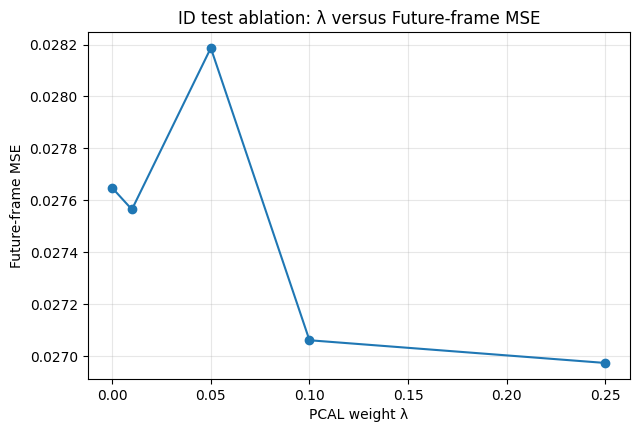

Saved figure: sora2_pcal_outputs/figures/ablation_future_psnr.png


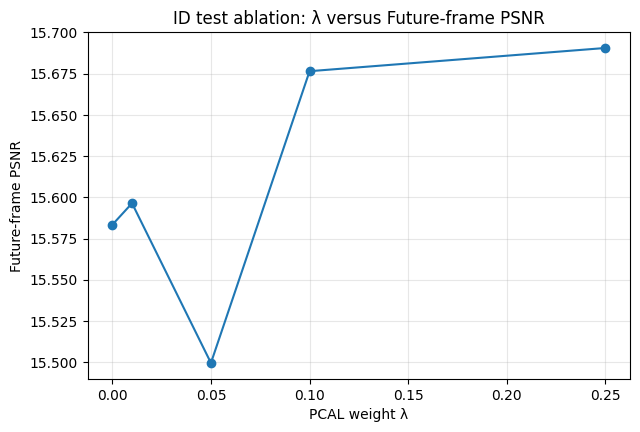

Saved figure: sora2_pcal_outputs/figures/ablation_position_error.png


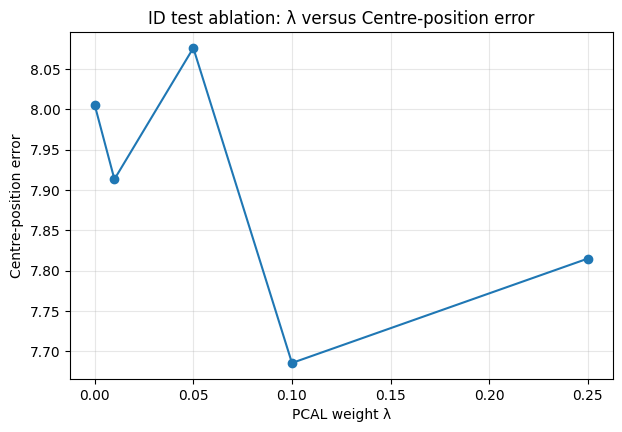

Saved figure: sora2_pcal_outputs/figures/ablation_velocity_error.png


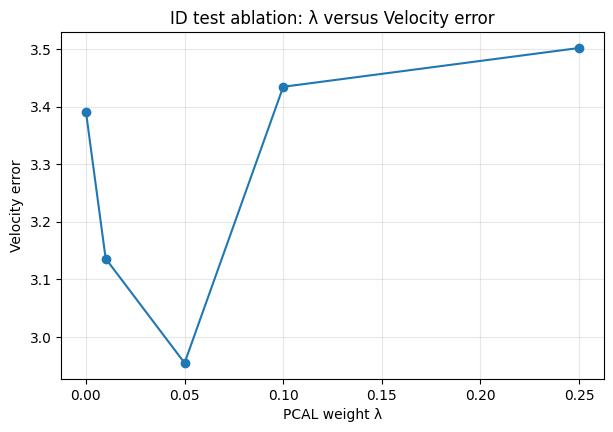

Saved figure: sora2_pcal_outputs/figures/ablation_acceleration_error.png


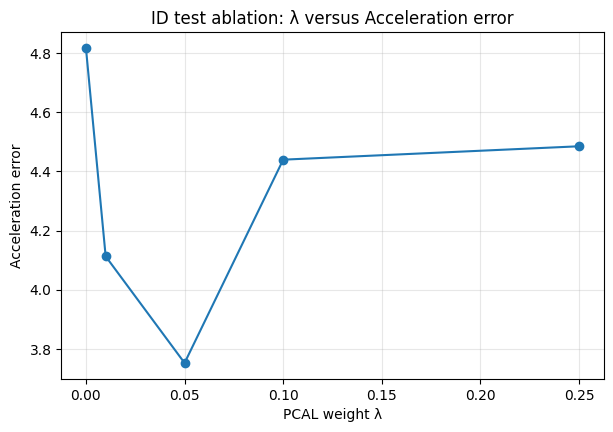

Saved figure: sora2_pcal_outputs/figures/ablation_boundary_violation_rate.png


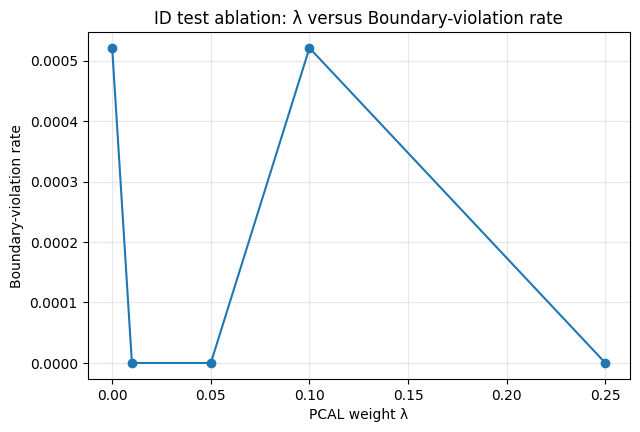

In [ ]:
# 9.3 Ablation plots

id_results = results_df[results_df['split'] == 'ID_test'].sort_values('lambda_pcal')

metrics_to_plot = [
    ('future_mse', 'Future-frame MSE'),
    ('future_psnr', 'Future-frame PSNR'),
    ('position_error', 'Centre-position error'),
    ('velocity_error', 'Velocity error'),
    ('acceleration_error', 'Acceleration error'),
    ('boundary_violation_rate', 'Boundary-violation rate'),
]

for metric_name, metric_label in metrics_to_plot:
    plt.figure(figsize=(7, 4.5))
    plt.plot(id_results['lambda_pcal'], id_results[metric_name], marker='o')
    plt.xlabel('PCAL weight λ')
    plt.ylabel(metric_label)
    plt.title(f'ID test ablation: λ versus {metric_label}')
    plt.grid(True, alpha=0.3)
    save_current_figure(f'ablation_{metric_name}.png')
    plt.show()

# 10. Qualitative comparison

The following comparisons use the same context videos and the same sampling seed for baseline and PCAL.

Saved figure: sora2_pcal_outputs/figures/qualitative_example_1_ground_truth.png


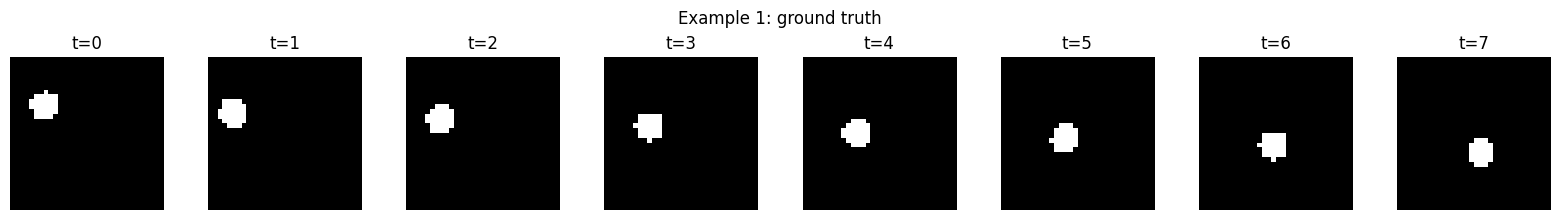

Saved figure: sora2_pcal_outputs/figures/qualitative_example_1_baseline.png


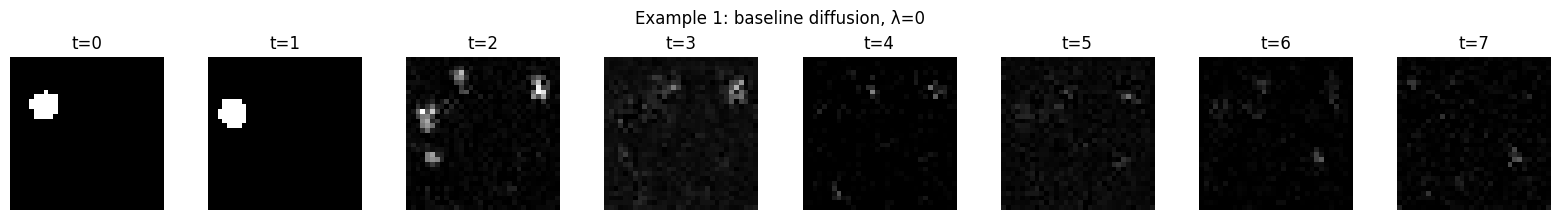

Saved figure: sora2_pcal_outputs/figures/qualitative_example_1_pcal.png


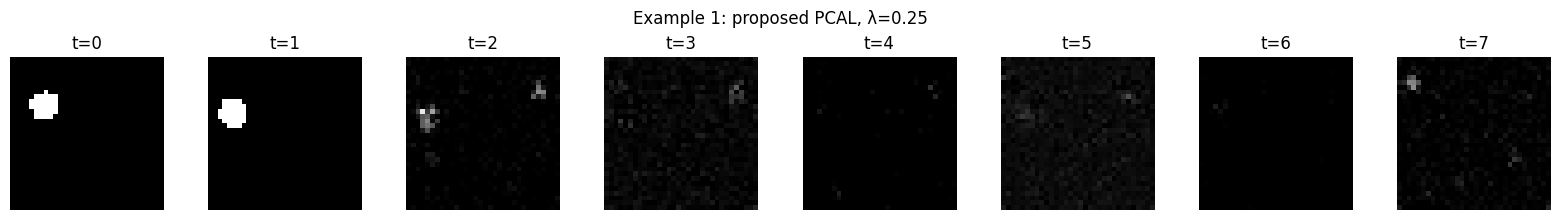

Saved figure: sora2_pcal_outputs/figures/qualitative_example_2_ground_truth.png


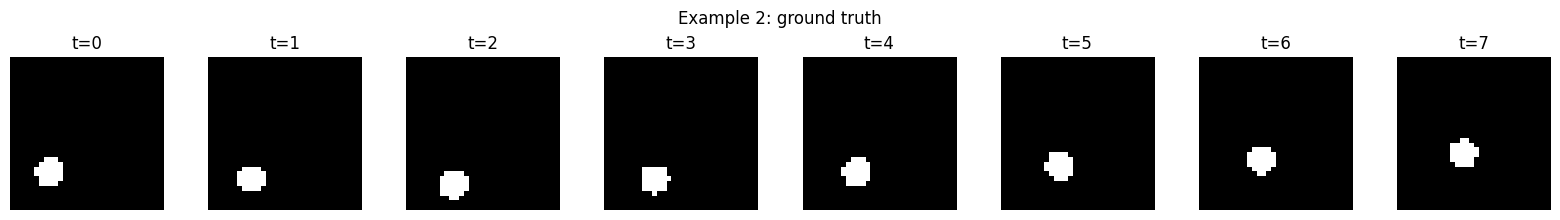

Saved figure: sora2_pcal_outputs/figures/qualitative_example_2_baseline.png


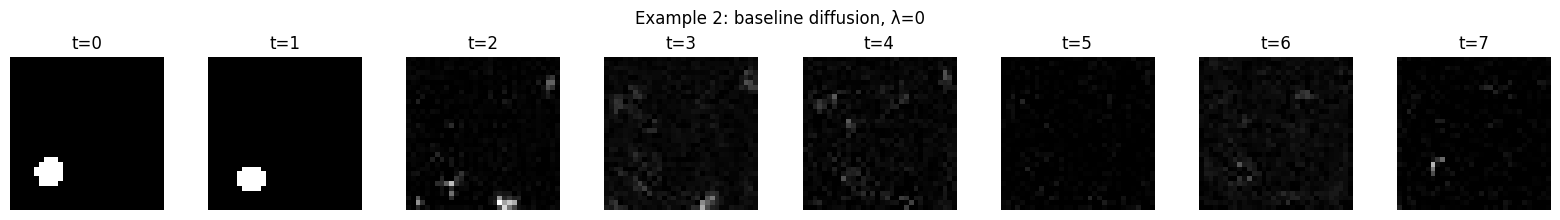

Saved figure: sora2_pcal_outputs/figures/qualitative_example_2_pcal.png


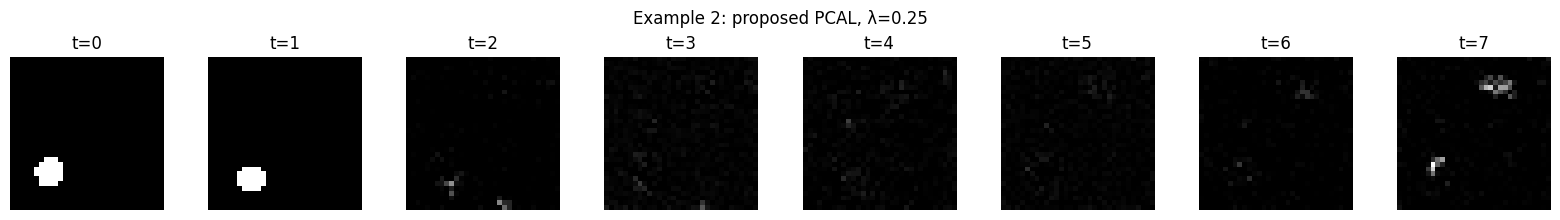

Saved figure: sora2_pcal_outputs/figures/qualitative_example_3_ground_truth.png


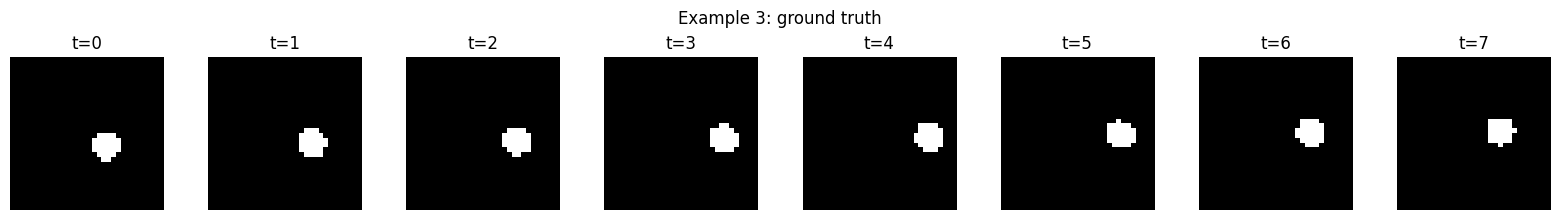

Saved figure: sora2_pcal_outputs/figures/qualitative_example_3_baseline.png


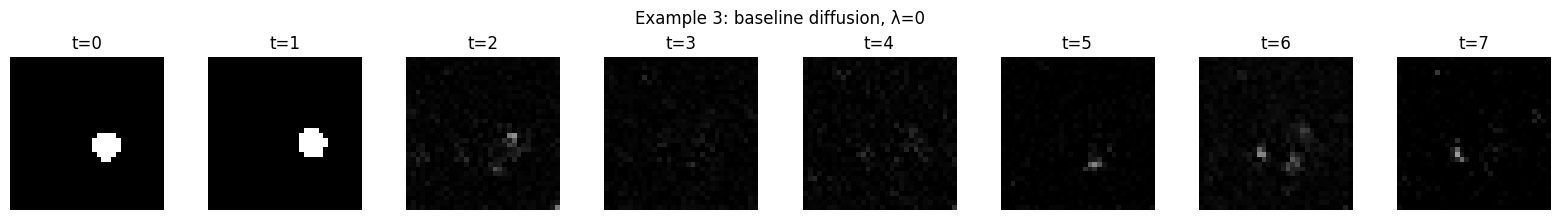

Saved figure: sora2_pcal_outputs/figures/qualitative_example_3_pcal.png


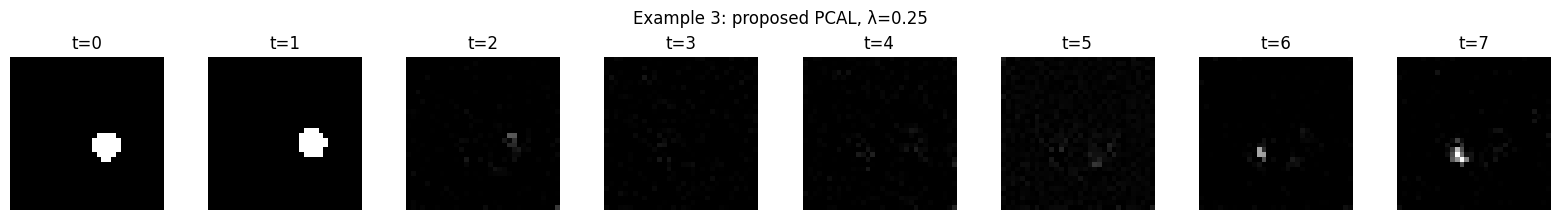

In [ ]:
# 10.1 Generated frame strips

@torch.no_grad()
def make_comparison_examples(
    loader: DataLoader,
    baseline_model: nn.Module,
    proposed_model: nn.Module,
    n_examples: int,
    sampling_seed: int,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    videos, positions = next(iter(loader))
    videos = videos[:n_examples].to(DEVICE)
    positions = positions[:n_examples].to(DEVICE)
    context = videos[:, :cfg.context_frames]

    baseline_future = sample_future(baseline_model, context, seed=sampling_seed)
    proposed_future = sample_future(proposed_model, context, seed=sampling_seed)

    baseline_full = torch.cat([context, baseline_future], dim=1)
    proposed_full = torch.cat([context, proposed_future], dim=1)

    return videos, positions, baseline_full, proposed_full


ground_truth, ground_truth_positions, baseline_generated, proposed_generated = make_comparison_examples(
    loader=test_loader,
    baseline_model=models[0.0],
    proposed_model=models[best_lambda],
    n_examples=cfg.samples_to_plot,
    sampling_seed=cfg.seed + 3000,
)

for index in range(cfg.samples_to_plot):
    show_video_strip(
        ground_truth[index],
        f'Example {index + 1}: ground truth',
        f'qualitative_example_{index + 1}_ground_truth.png',
    )
    show_video_strip(
        baseline_generated[index],
        f'Example {index + 1}: baseline diffusion, λ=0',
        f'qualitative_example_{index + 1}_baseline.png',
    )
    show_video_strip(
        proposed_generated[index],
        f'Example {index + 1}: proposed PCAL, λ={best_lambda}',
        f'qualitative_example_{index + 1}_pcal.png',
    )

Saved figure: sora2_pcal_outputs/figures/trajectory_example_1.png


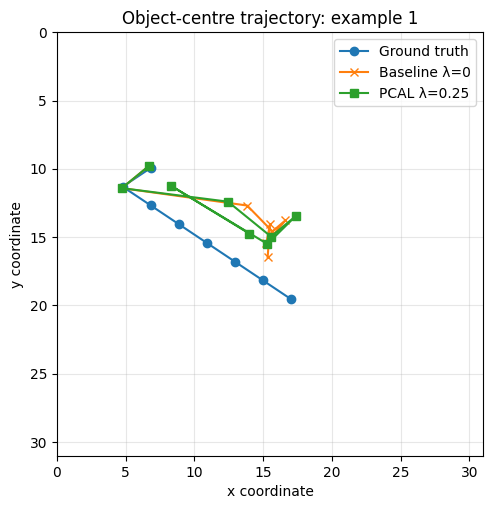

Saved figure: sora2_pcal_outputs/figures/trajectory_example_2.png


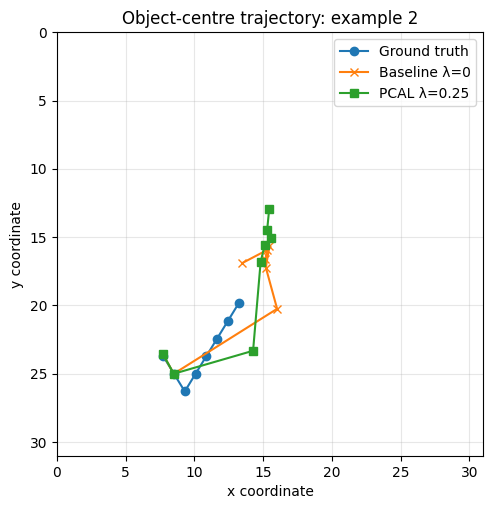

Saved figure: sora2_pcal_outputs/figures/trajectory_example_3.png


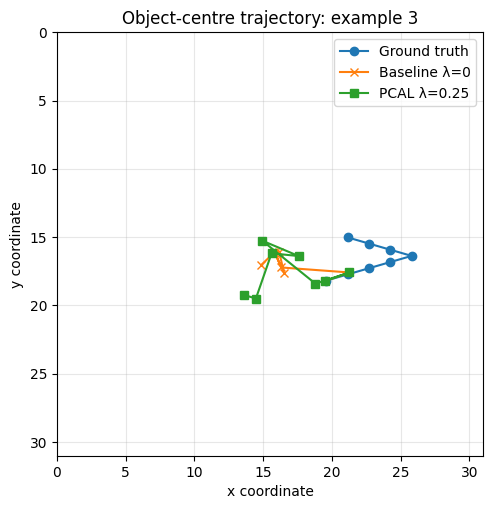

In [ ]:
# 10.2 Trajectory comparison plots

baseline_positions = extract_centres(baseline_generated)
proposed_positions = extract_centres(proposed_generated)

for index in range(cfg.samples_to_plot):
    gt = ground_truth_positions[index].detach().cpu().numpy()
    base = baseline_positions[index].detach().cpu().numpy()
    prop = proposed_positions[index].detach().cpu().numpy()

    plt.figure(figsize=(5.5, 5.5))
    plt.plot(gt[:, 0], gt[:, 1], marker='o', label='Ground truth')
    plt.plot(base[:, 0], base[:, 1], marker='x', label='Baseline λ=0')
    plt.plot(prop[:, 0], prop[:, 1], marker='s', label=f'PCAL λ={best_lambda}')

    plt.xlim(0, cfg.image_size - 1)
    plt.ylim(cfg.image_size - 1, 0)
    plt.xlabel('x coordinate')
    plt.ylabel('y coordinate')
    plt.title(f'Object-centre trajectory: example {index + 1}')
    plt.grid(True, alpha=0.3)
    plt.legend()
    save_current_figure(f'trajectory_example_{index + 1}.png')
    plt.show()

# 11. Baseline versus selected PCAL summary


In [ ]:
# 11.1 Summary table: baseline vs selected PCAL

baseline_id = results_df[
    (results_df['lambda_pcal'] == 0.0) & (results_df['split'] == 'ID_test')
].iloc[0]

proposed_id = results_df[
    (results_df['lambda_pcal'] == best_lambda) & (results_df['split'] == 'ID_test')
].iloc[0]

summary_metrics = [
    'future_mse',
    'future_mae',
    'future_psnr',
    'global_ssim_proxy',
    'position_error',
    'velocity_error',
    'acceleration_error',
    'predicted_acceleration_magnitude',
    'boundary_violation_rate',
    'sampling_seconds_per_batch',
    'training_seconds',
]

summary_rows = []
for metric in summary_metrics:
    baseline_value = float(baseline_id[metric])
    proposed_value = float(proposed_id[metric])

    if baseline_value != 0.0 and np.isfinite(baseline_value):
        percentage_change = 100.0 * (proposed_value - baseline_value) / baseline_value
    else:
        percentage_change = np.nan

    summary_rows.append(
        {
            'metric': metric,
            'baseline_lambda_0': baseline_value,
            f'selected_pcal_lambda_{best_lambda}': proposed_value,
            'percentage_change_vs_baseline': percentage_change,
            'preferred_direction': 'higher is better' if metric in ['future_psnr', 'global_ssim_proxy'] else 'lower is better',
        }
    )

baseline_vs_pcal_df = pd.DataFrame(summary_rows)
summary_csv = CSV_DIR / 'baseline_vs_selected_pcal_summary.csv'
baseline_vs_pcal_df.to_csv(summary_csv, index=False)

print('Baseline vs PCAL summary saved to:', summary_csv)
display(baseline_vs_pcal_df)

Baseline vs PCAL summary saved to: sora2_pcal_outputs/csv/baseline_vs_selected_pcal_summary.csv


,metric,baseline_lambda_0,selected_pcal_lambda_0.25,percentage_change_vs_baseline,preferred_direction
0,future_mse,0.027648,0.026974,-2.438430,lower is better
1,future_mae,0.052545,0.037825,-28.014022,lower is better
2,future_psnr,15.583394,15.690593,0.687906,higher is better
3,global_ssim_proxy,0.090326,0.058741,-34.967402,higher is better
4,position_error,8.005621,7.815091,-2.379952,lower is better
5,velocity_error,3.391449,3.502195,3.265444,lower is better
6,acceleration_error,4.816631,4.484683,-6.891718,lower is better
7,predicted_acceleration_magnitude,4.740521,4.434231,-6.461095,lower is better
8,boundary_violation_rate,0.000521,0.000000,-100.000000,lower is better
9,sampling_seconds_per_batch,0.433391,0.431057,-0.538622,lower is better


In [ ]:
# 11.2 Automatically generated interpretation aid

def better_direction(metric: str) -> str:
    if metric in ['future_psnr', 'global_ssim_proxy']:
        return 'higher'
    return 'lower'


print('Interpretation aid for the report')
print('=' * 60)

for metric in [
    'future_mse',
    'future_psnr',
    'position_error',
    'velocity_error',
    'acceleration_error',
    'boundary_violation_rate',
]:
    baseline_value = float(baseline_id[metric])
    proposed_value = float(proposed_id[metric])
    direction = better_direction(metric)

    improved = proposed_value < baseline_value if direction == 'lower' else proposed_value > baseline_value
    status = 'improved' if improved else 'did not improve'
    print(
        f'{metric}: baseline={baseline_value:.5f}, '
        f'PCAL={proposed_value:.5f} → {status} '
        f'({direction} is better).'
    )

print('\nSelected λ:', best_lambda)
print('Selection reason:', selection_reason)

Interpretation aid for the report
future_mse: baseline=0.02765, PCAL=0.02697 → improved (lower is better).
future_psnr: baseline=15.58339, PCAL=15.69059 → improved (higher is better).
position_error: baseline=8.00562, PCAL=7.81509 → improved (lower is better).
velocity_error: baseline=3.39145, PCAL=3.50219 → did not improve (lower is better).
acceleration_error: baseline=4.81663, PCAL=4.48468 → improved (lower is better).
boundary_violation_rate: baseline=0.00052, PCAL=0.00000 → improved (lower is better).

Selected λ: 0.25
Selection reason: lowest validation PCAL among non-zero lambdas within 15% of baseline validation noise loss


# 12. Export artefacts


In [ ]:
# 12.1 Save configuration and create output zip

config_path = OUTPUT_DIR / 'config.json'
with open(config_path, 'w') as f:
    json.dump(asdict(cfg), f, indent=2)

manifest = {
    'notebook_purpose': 'Sora 2-inspired PCAL video diffusion artefact',
    'claim_boundary': 'Does not reproduce or improve proprietary Sora 2; evaluates PCAL in a controlled proxy.',
    'quick_run': cfg.quick_run,
    'selected_lambda': best_lambda,
    'selection_reason': selection_reason,
    'parameter_count': parameter_count,
    'outputs': {
        'config': str(config_path),
        'training_history_csv': str(history_csv),
        'evaluation_metrics_csv': str(results_csv),
        'baseline_vs_pcal_summary_csv': str(summary_csv),
        'figure_dir': str(FIGURE_DIR),
        'checkpoint_dir': str(CHECKPOINT_DIR),
    },
}

manifest_path = OUTPUT_DIR / 'manifest.json'
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)

zip_path = Path('sora2_pcal_outputs.zip')
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for path in OUTPUT_DIR.rglob('*'):
        if path.is_file():
            zf.write(path, arcname=path.relative_to(OUTPUT_DIR.parent))

print('Saved configuration:', config_path)
print('Saved manifest:', manifest_path)
print('Created output archive:', zip_path)

Saved configuration: sora2_pcal_outputs/config.json
Saved manifest: sora2_pcal_outputs/manifest.json
Created output archive: sora2_pcal_outputs.zip
